In [ ]:
from google.colab  import drive
drive.mount('/content/drive')


Mounted at /content/drive



===== Running GA for KNN =====


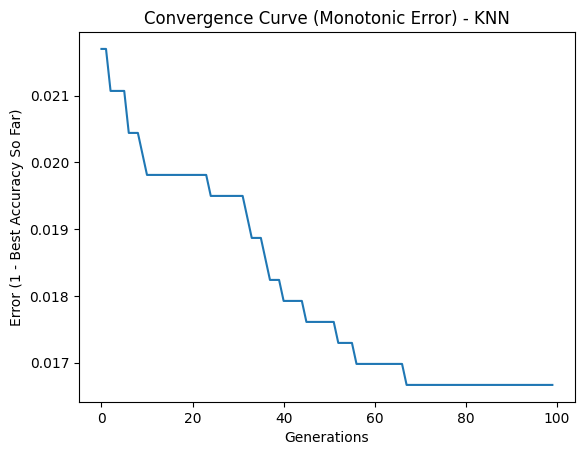

Selected Features: [0, 1, 4, 5, 7, 8, 12, 13, 14, 19, 21, 25, 26, 28, 29, 33, 34, 37]
Without FS: {'Accuracy': 0.9773869346733668, 'Precision': 0.5, 'Recall': 0.1111111111111111, 'F1': 0.18181818181818182}
With FS: {'Accuracy': 0.9773869346733668, 'Precision': 0.5, 'Recall': 0.1111111111111111, 'F1': 0.18181818181818182}

===== Running GA for Naive Bayes =====


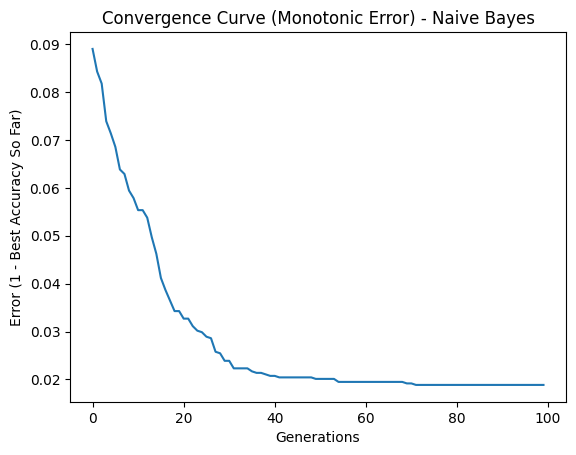

Selected Features: [0, 6, 7, 17, 18, 26, 27, 28, 37]
Without FS: {'Accuracy': 0.9045226130653267, 'Precision': 0.06060606060606061, 'Recall': 0.2222222222222222, 'F1': 0.09523809523809523}
With FS: {'Accuracy': 0.9698492462311558, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== Running GA for QDA =====


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


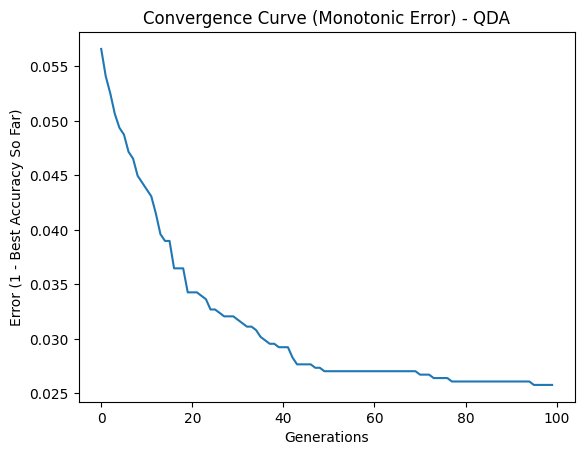

Selected Features: [2, 9, 10, 17, 20, 27, 28, 29]
Without FS: {'Accuracy': 0.949748743718593, 'Precision': 0.07692307692307693, 'Recall': 0.1111111111111111, 'F1': 0.09090909090909091}
With FS: {'Accuracy': 0.964824120603015, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== Running GA for Random Forest =====


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


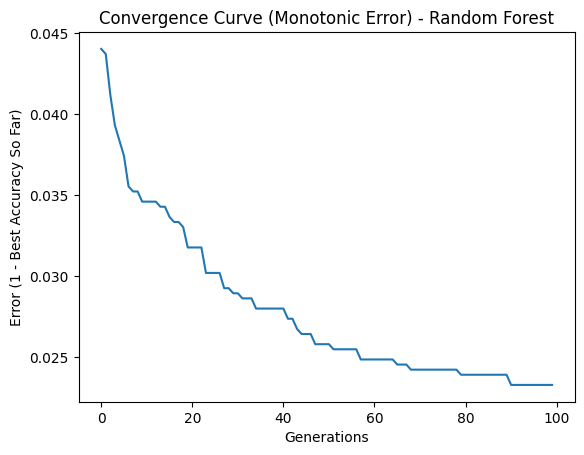

Selected Features: [3, 4, 6, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 26, 29, 31, 32, 33, 35, 37, 38]
Without FS: {'Accuracy': 0.9195979899497487, 'Precision': 0.04, 'Recall': 0.1111111111111111, 'F1': 0.058823529411764705}
With FS: {'Accuracy': 0.9221105527638191, 'Precision': 0.07692307692307693, 'Recall': 0.2222222222222222, 'F1': 0.11428571428571428}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.977387            0.977387   0.500000  0.111111   
1    Naive Bayes          0.904523            0.969849   0.000000  0.000000   
2            QDA          0.949749            0.964824   0.000000  0.000000   
3  Random Forest          0.919598            0.922111   0.076923  0.222222   

         F1  
0  0.181818  
1  0.000000  
2  0.000000  
3  0.114286  


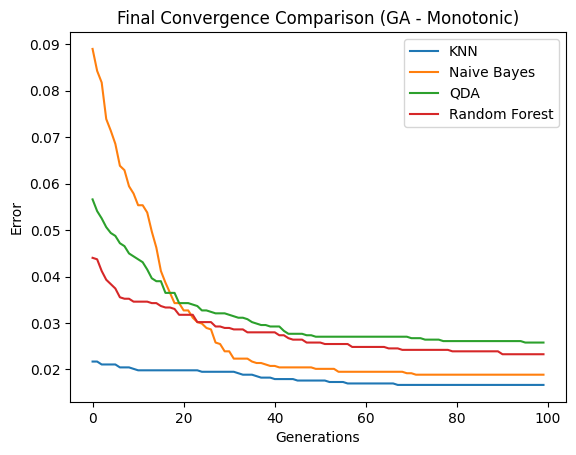


  Avg Execution Time : 478.7806 s
  Avg Memory Used    : 14.9038 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) -
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-MC1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = [fitness(ind, model) for ind in population]

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running GA for KNN =====


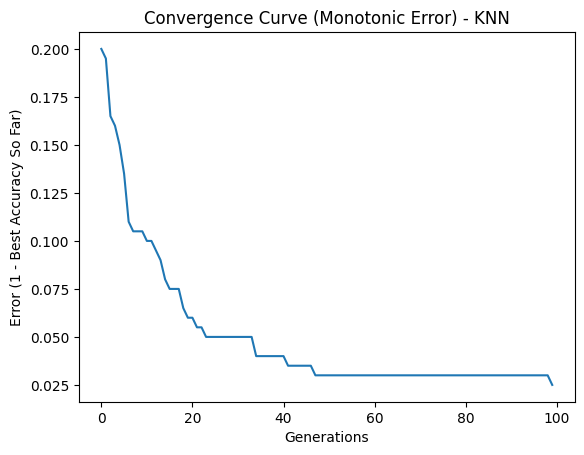

Selected Features: [2, 3, 5, 6, 8, 12, 14, 18, 19, 20, 21, 22, 26, 27, 30, 31, 33, 35, 36, 37, 38]
Without FS: {'Accuracy': 0.68, 'Precision': 0.6666666666666666, 'Recall': 0.2222222222222222, 'F1': 0.3333333333333333}
With FS: {'Accuracy': 0.6, 'Precision': 0.4, 'Recall': 0.2222222222222222, 'F1': 0.2857142857142857}

===== Running GA for Naive Bayes =====


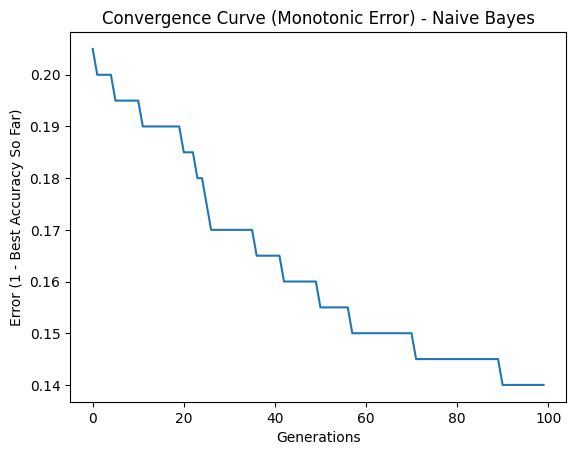

Selected Features: [3, 6, 8, 9, 10, 11, 12, 17, 19, 20, 21, 25, 35, 36, 38, 39]
Without FS: {'Accuracy': 0.68, 'Precision': 0.6666666666666666, 'Recall': 0.2222222222222222, 'F1': 0.3333333333333333}
With FS: {'Accuracy': 0.64, 'Precision': 0.5, 'Recall': 0.3333333333333333, 'F1': 0.4}

===== Running GA for QDA =====


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

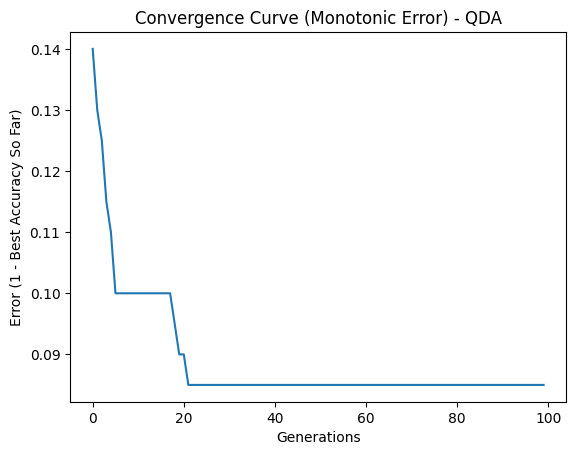

Selected Features: [1, 3, 5, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 24, 25, 28, 33, 35, 38]
Without FS: {'Accuracy': 0.64, 'Precision': 0.5, 'Recall': 0.1111111111111111, 'F1': 0.18181818181818182}
With FS: {'Accuracy': 0.56, 'Precision': 0.25, 'Recall': 0.1111111111111111, 'F1': 0.15384615384615385}

===== Running GA for Random Forest =====


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


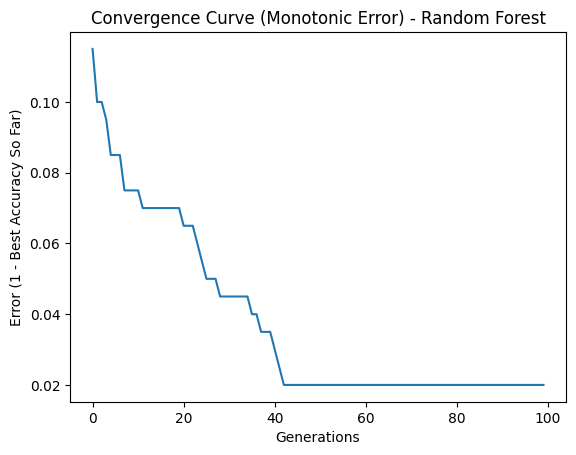

Selected Features: [0, 1, 3, 7, 9, 10, 11, 13, 15, 16, 18, 19, 20, 21, 23, 24, 26, 31, 32, 33, 34, 35, 36, 37, 39]
Without FS: {'Accuracy': 0.56, 'Precision': 0.25, 'Recall': 0.1111111111111111, 'F1': 0.15384615384615385}
With FS: {'Accuracy': 0.64, 'Precision': 0.5, 'Recall': 0.5555555555555556, 'F1': 0.5263157894736842}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN              0.68                0.60       0.40  0.222222   
1    Naive Bayes              0.68                0.64       0.50  0.333333   
2            QDA              0.64                0.56       0.25  0.111111   
3  Random Forest              0.56                0.64       0.50  0.555556   

         F1  
0  0.285714  
1  0.400000  
2  0.153846  
3  0.526316  


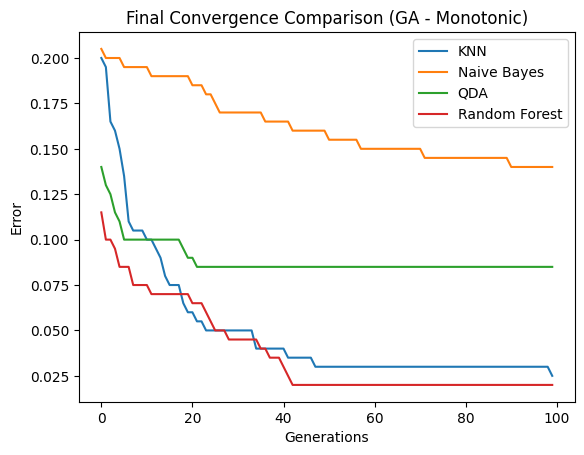


  Avg Execution Time : 449.1767 s
  Avg Memory Used    : 14.5396 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) -
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-MC2.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = [fitness(ind, model) for ind in population]

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running GA for KNN =====


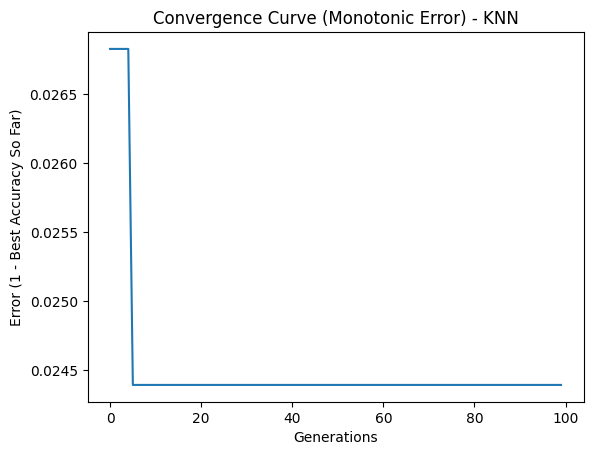

Selected Features: [1, 9, 10, 11, 12, 13, 17, 22, 25, 28, 29, 30, 32, 33, 34, 36, 37]
Without FS: {'Accuracy': 0.8235294117647058, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.8431372549019608, 'Precision': 0.3333333333333333, 'Recall': 0.6, 'F1': 0.42857142857142855}

===== Running GA for Naive Bayes =====


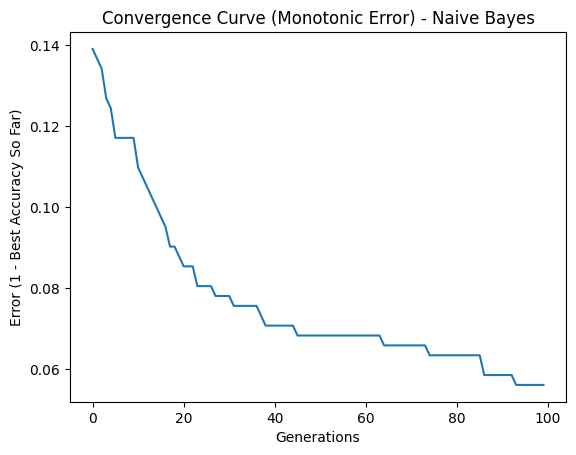

Selected Features: [3, 5, 6, 8, 12, 15, 17, 30]
Without FS: {'Accuracy': 0.7254901960784313, 'Precision': 0.2, 'Recall': 0.6, 'F1': 0.3}
With FS: {'Accuracy': 0.7843137254901961, 'Precision': 0.25, 'Recall': 0.6, 'F1': 0.35294117647058826}

===== Running GA for QDA =====


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing 

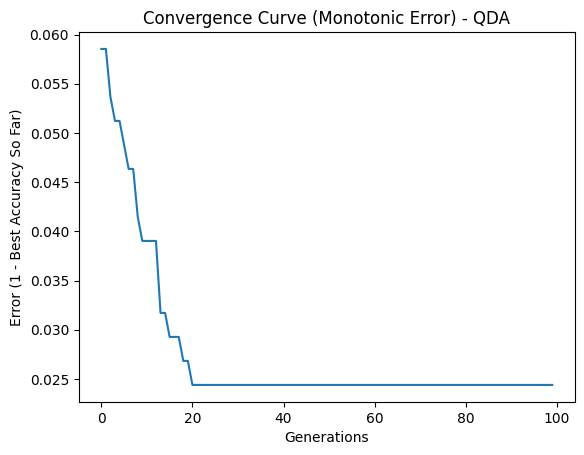

Selected Features: [8, 12, 14, 17, 18, 21, 23, 25, 26, 27, 28, 30, 31, 37]
Without FS: {'Accuracy': 0.8823529411764706, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.8235294117647058, 'Precision': 0.3, 'Recall': 0.6, 'F1': 0.4}

===== Running GA for Random Forest =====


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


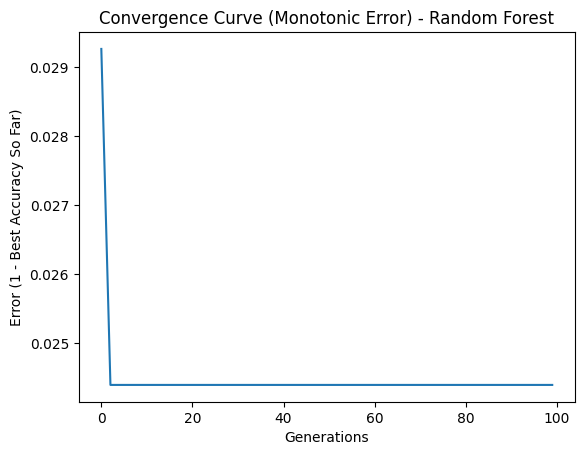

Selected Features: [0, 1, 3, 4, 9, 11, 15, 16, 17, 20, 23, 25, 26, 27, 28, 31, 34, 37]
Without FS: {'Accuracy': 0.7647058823529411, 'Precision': 0.23076923076923078, 'Recall': 0.6, 'F1': 0.3333333333333333}
With FS: {'Accuracy': 0.803921568627451, 'Precision': 0.2727272727272727, 'Recall': 0.6, 'F1': 0.375}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision  Recall  \
0            KNN          0.823529            0.843137   0.333333     0.6   
1    Naive Bayes          0.725490            0.784314   0.250000     0.6   
2            QDA          0.882353            0.823529   0.300000     0.6   
3  Random Forest          0.764706            0.803922   0.272727     0.6   

         F1  
0  0.428571  
1  0.352941  
2  0.400000  
3  0.375000  


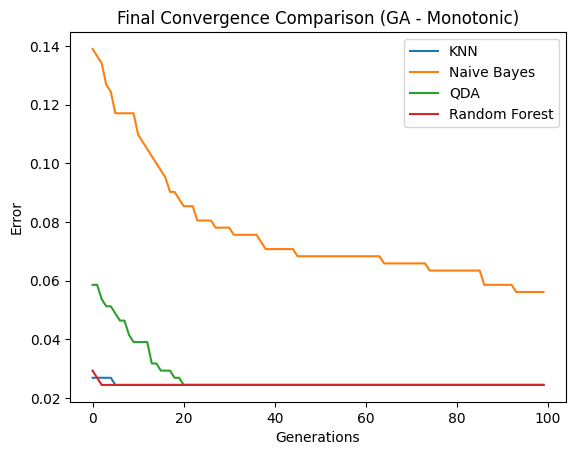


  Avg Execution Time : 435.9473 s
  Avg Memory Used    : 13.8991 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) -
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-MW1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = [fitness(ind, model) for ind in population]

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running GA for KNN =====


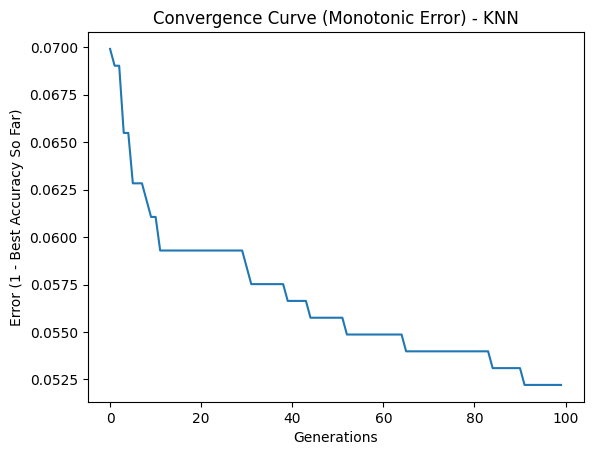

Selected Features: [3, 5, 7, 8, 10, 13, 16, 19, 20, 22, 25, 30, 31, 32, 34, 35, 37]
Without FS: {'Accuracy': 0.8865248226950354, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.8936170212765957, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== Running GA for Naive Bayes =====


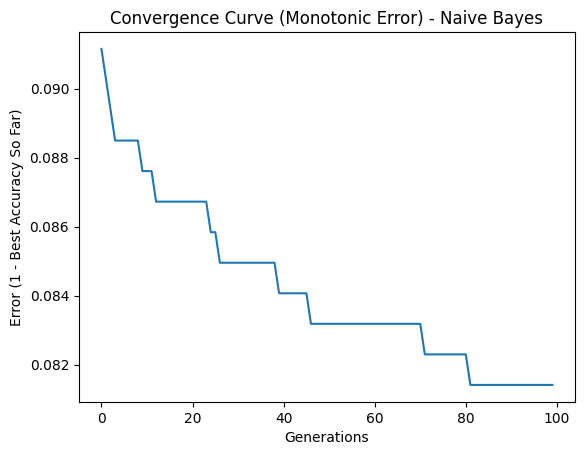

Selected Features: [0, 1, 4, 7, 8, 13, 14, 15, 17, 20, 25, 26, 30, 33, 35, 37]
Without FS: {'Accuracy': 0.8865248226950354, 'Precision': 0.25, 'Recall': 0.16666666666666666, 'F1': 0.2}
With FS: {'Accuracy': 0.900709219858156, 'Precision': 0.3333333333333333, 'Recall': 0.16666666666666666, 'F1': 0.2222222222222222}

===== Running GA for QDA =====


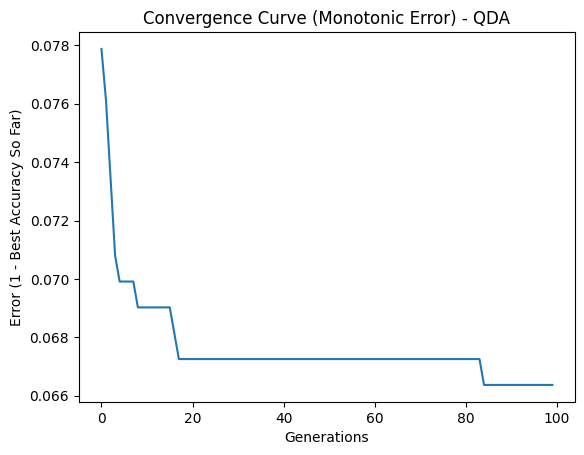

Selected Features: [8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 23, 27, 28, 29, 34, 35]
Without FS: {'Accuracy': 0.851063829787234, 'Precision': 0.15384615384615385, 'Recall': 0.16666666666666666, 'F1': 0.16}
With FS: {'Accuracy': 0.8936170212765957, 'Precision': 0.2857142857142857, 'Recall': 0.16666666666666666, 'F1': 0.21052631578947367}

===== Running GA for Random Forest =====


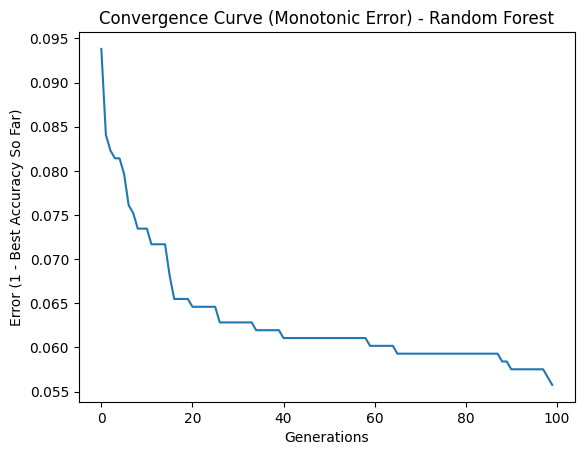

Selected Features: [0, 3, 7, 10, 13, 15, 16, 18, 19, 21, 22, 23, 25, 27, 31, 33, 35, 36]
Without FS: {'Accuracy': 0.8156028368794326, 'Precision': 0.15, 'Recall': 0.25, 'F1': 0.1875}
With FS: {'Accuracy': 0.7943262411347518, 'Precision': 0.20689655172413793, 'Recall': 0.5, 'F1': 0.2926829268292683}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.886525            0.893617   0.000000  0.000000   
1    Naive Bayes          0.886525            0.900709   0.333333  0.166667   
2            QDA          0.851064            0.893617   0.285714  0.166667   
3  Random Forest          0.815603            0.794326   0.206897  0.500000   

         F1  
0  0.000000  
1  0.222222  
2  0.210526  
3  0.292683  


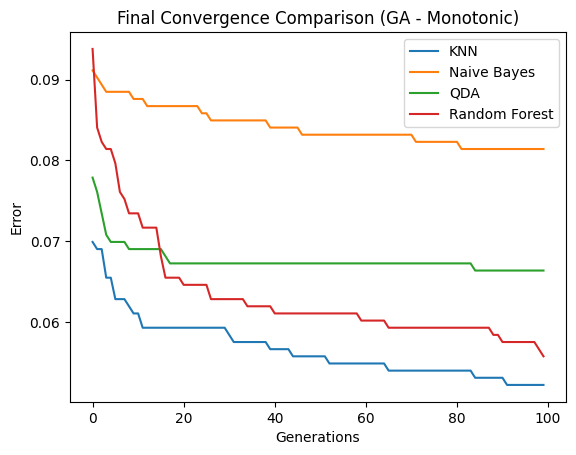


  Avg Execution Time : 450.1119 s
  Avg Memory Used    : 14.1137 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) -
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-PC1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = [fitness(ind, model) for ind in population]

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running GA for KNN =====


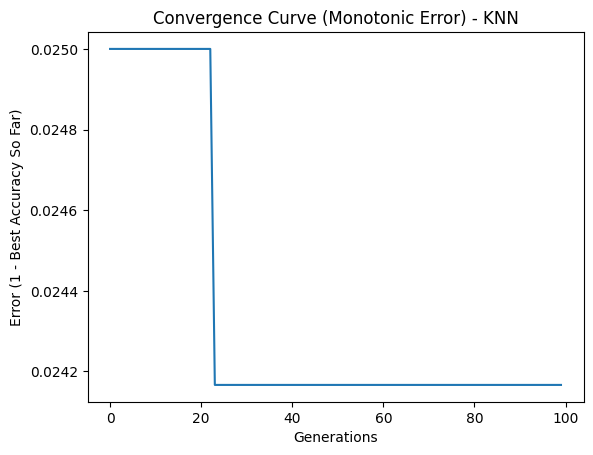

Selected Features: [0, 1, 2, 3, 4, 7, 8, 11, 12, 14, 15, 19, 20, 21, 27, 28, 30, 31, 33, 34, 35]
Without FS: {'Accuracy': 0.9798657718120806, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.9798657718120806, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== Running GA for Naive Bayes =====


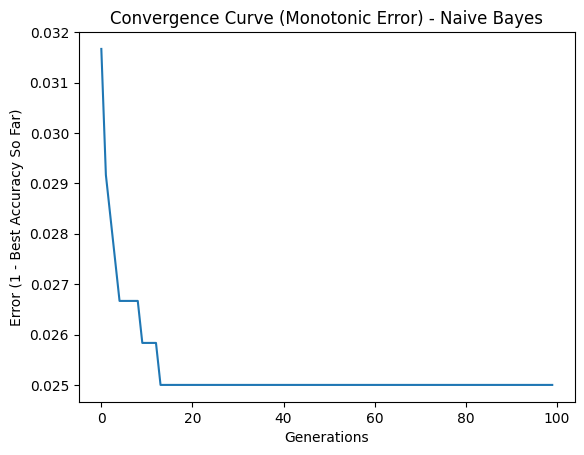

Selected Features: [1, 7, 8, 12, 15, 16, 17, 23, 24, 25, 27, 35]
Without FS: {'Accuracy': 0.912751677852349, 'Precision': 0.08333333333333333, 'Recall': 0.3333333333333333, 'F1': 0.13333333333333333}
With FS: {'Accuracy': 0.959731543624161, 'Precision': 0.2, 'Recall': 0.3333333333333333, 'F1': 0.25}

===== Running GA for QDA =====


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing 

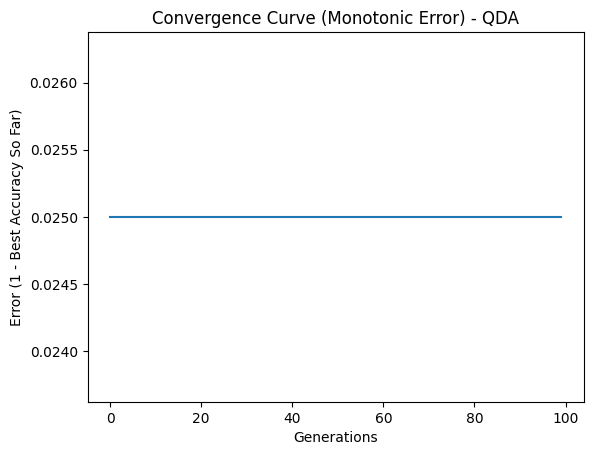

Selected Features: [3, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 19, 22, 30, 31, 33, 35, 36]
Without FS: {'Accuracy': 0.9798657718120806, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.9798657718120806, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== Running GA for Random Forest =====


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


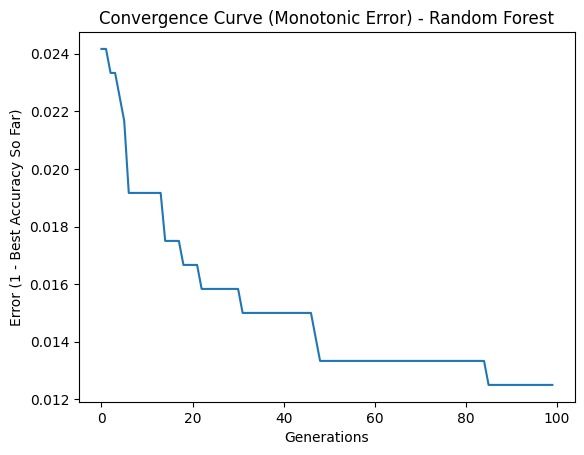

Selected Features: [0, 3, 4, 11, 12, 14, 16, 17, 18, 19, 21, 25, 29, 31, 33, 34]
Without FS: {'Accuracy': 0.9060402684563759, 'Precision': 0.07692307692307693, 'Recall': 0.3333333333333333, 'F1': 0.125}
With FS: {'Accuracy': 0.8993288590604027, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.979866            0.979866        0.0  0.000000   
1    Naive Bayes          0.912752            0.959732        0.2  0.333333   
2            QDA          0.979866            0.979866        0.0  0.000000   
3  Random Forest          0.906040            0.899329        0.0  0.000000   

     F1  
0  0.00  
1  0.25  
2  0.00  
3  0.00  


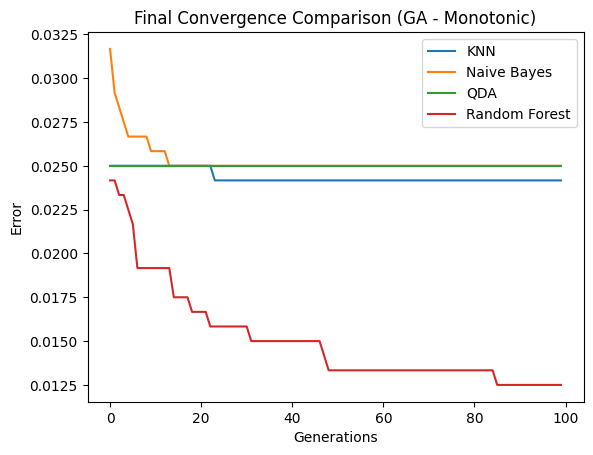


  Avg Execution Time : 458.0991 s
  Avg Memory Used    : 13.8297 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) -
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-PC2.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = [fitness(ind, model) for ind in population]

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running GA for KNN =====


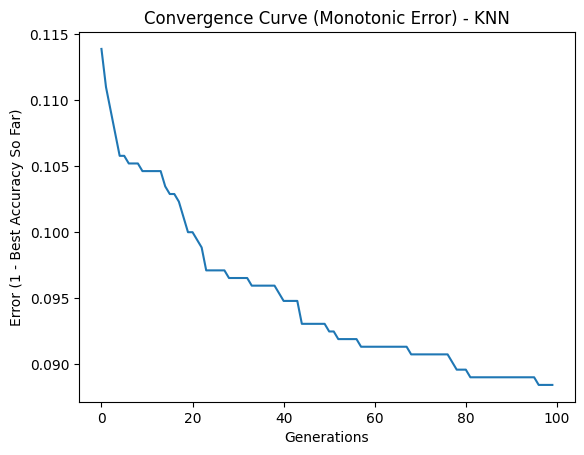

Selected Features: [0, 1, 3, 6, 11, 18, 20, 22, 25, 28, 30, 31, 32, 34]
Without FS: {'Accuracy': 0.8796296296296297, 'Precision': 0.5714285714285714, 'Recall': 0.14814814814814814, 'F1': 0.23529411764705882}
With FS: {'Accuracy': 0.8657407407407407, 'Precision': 0.3333333333333333, 'Recall': 0.07407407407407407, 'F1': 0.12121212121212122}

===== Running GA for Naive Bayes =====


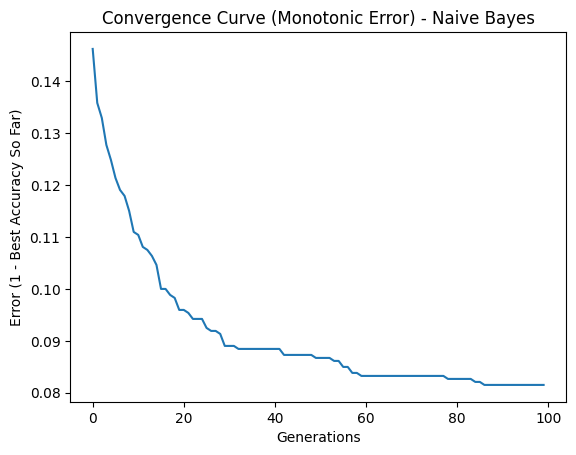

Selected Features: [0, 2, 4, 6, 8, 9, 10, 11, 12, 14, 15, 26, 27, 28, 31, 32, 34, 35]
Without FS: {'Accuracy': 0.3101851851851852, 'Precision': 0.1534090909090909, 'Recall': 1.0, 'F1': 0.2660098522167488}
With FS: {'Accuracy': 0.5925925925925926, 'Precision': 0.22018348623853212, 'Recall': 0.8888888888888888, 'F1': 0.35294117647058826}

===== Running GA for QDA =====


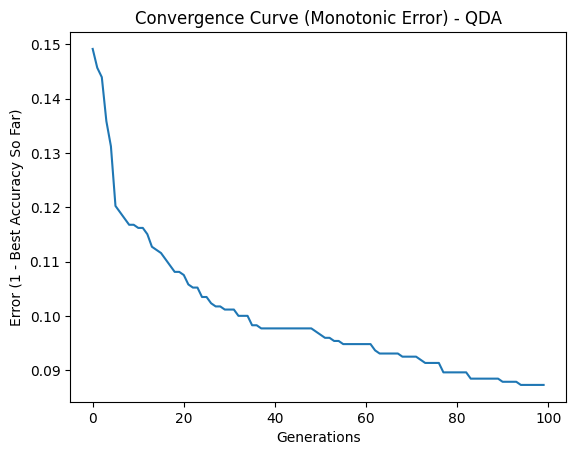

Selected Features: [0, 4, 6, 9, 12, 14, 15, 21, 25, 26, 28, 30, 33]
Without FS: {'Accuracy': 0.7037037037037037, 'Precision': 0.2823529411764706, 'Recall': 0.8888888888888888, 'F1': 0.42857142857142855}
With FS: {'Accuracy': 0.8564814814814815, 'Precision': 0.4, 'Recall': 0.2962962962962963, 'F1': 0.3404255319148936}

===== Running GA for Random Forest =====


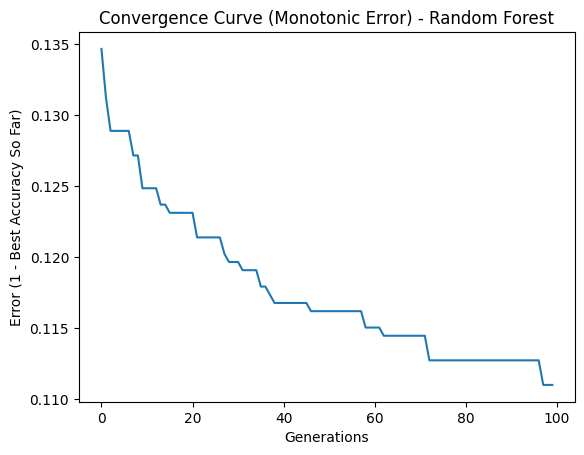

Selected Features: [1, 3, 4, 10, 11, 15, 17, 18, 20, 26, 28, 29, 31, 32, 33]
Without FS: {'Accuracy': 0.8009259259259259, 'Precision': 0.34615384615384615, 'Recall': 0.6666666666666666, 'F1': 0.45569620253164556}
With FS: {'Accuracy': 0.7638888888888888, 'Precision': 0.26, 'Recall': 0.48148148148148145, 'F1': 0.33766233766233766}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.879630            0.865741   0.333333  0.074074   
1    Naive Bayes          0.310185            0.592593   0.220183  0.888889   
2            QDA          0.703704            0.856481   0.400000  0.296296   
3  Random Forest          0.800926            0.763889   0.260000  0.481481   

         F1  
0  0.121212  
1  0.352941  
2  0.340426  
3  0.337662  


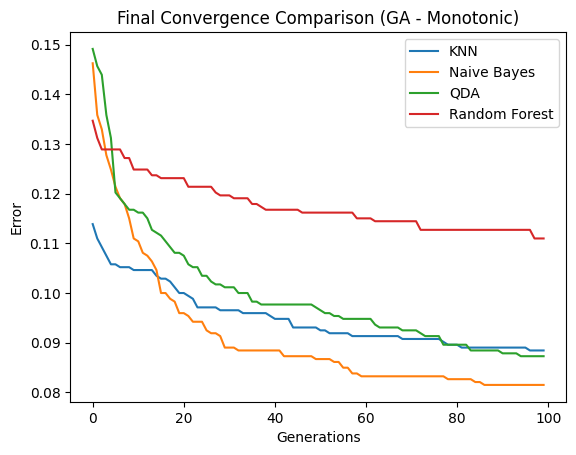


  Avg Execution Time : 457.7924 s
  Avg Memory Used    : 14.1903 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) -
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-PC3.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = [fitness(ind, model) for ind in population]

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running GA for KNN =====


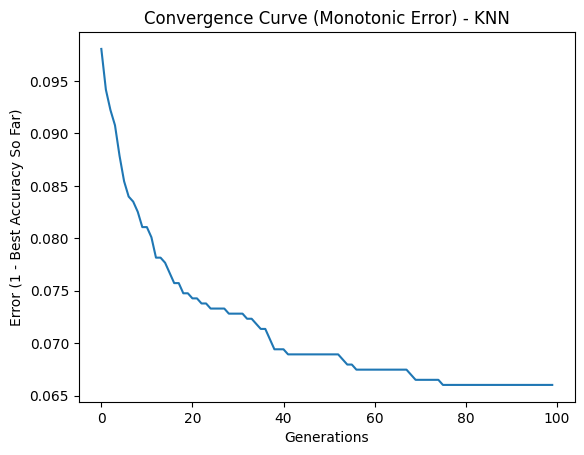

Selected Features: [0, 1, 2, 3, 4, 5, 6, 8, 9, 13, 14, 17, 18, 19, 22, 32, 35, 36]
Without FS: {'Accuracy': 0.8798449612403101, 'Precision': 0.5833333333333334, 'Recall': 0.4, 'F1': 0.4745762711864407}
With FS: {'Accuracy': 0.8953488372093024, 'Precision': 0.6666666666666666, 'Recall': 0.45714285714285713, 'F1': 0.5423728813559322}

===== Running GA for Naive Bayes =====


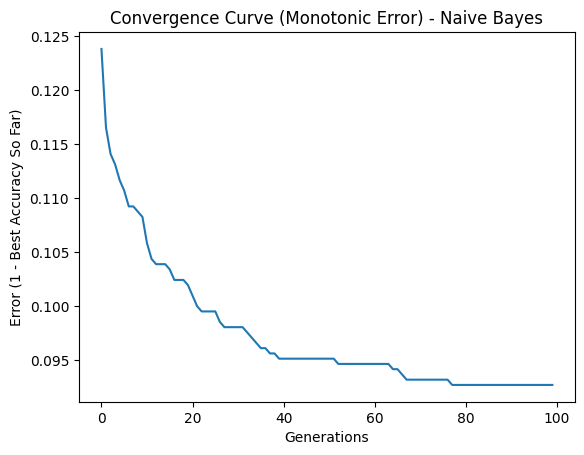

Selected Features: [0, 1, 2, 3, 4, 5, 7, 10, 11, 13, 14, 17, 25, 27, 33, 34, 35]
Without FS: {'Accuracy': 0.8604651162790697, 'Precision': 0.4782608695652174, 'Recall': 0.3142857142857143, 'F1': 0.3793103448275862}
With FS: {'Accuracy': 0.8953488372093024, 'Precision': 0.6818181818181818, 'Recall': 0.42857142857142855, 'F1': 0.5263157894736842}

===== Running GA for QDA =====


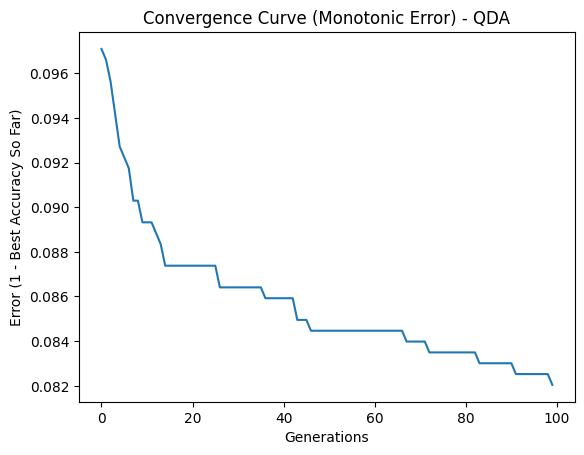

Selected Features: [0, 3, 4, 5, 7, 8, 9, 10, 11, 13, 14, 17, 19, 20, 22, 24, 25, 26, 29, 32, 35, 36, 37]
Without FS: {'Accuracy': 0.8798449612403101, 'Precision': 0.55, 'Recall': 0.6285714285714286, 'F1': 0.5866666666666667}
With FS: {'Accuracy': 0.9069767441860465, 'Precision': 0.7391304347826086, 'Recall': 0.4857142857142857, 'F1': 0.5862068965517241}

===== Running GA for Random Forest =====


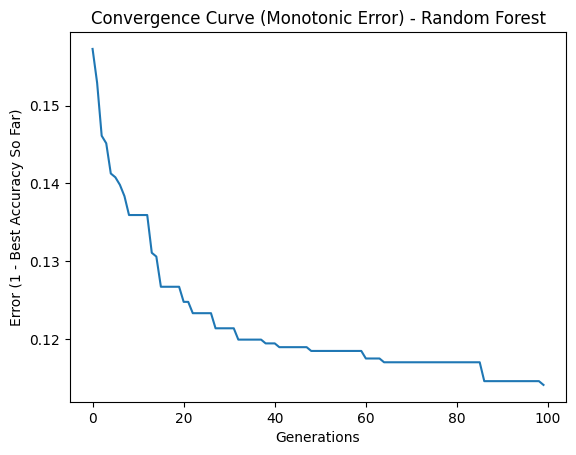

Selected Features: [2, 4, 5, 7, 8, 13, 15, 16, 17, 19, 22, 23, 25, 26, 29, 30, 32, 35, 36]
Without FS: {'Accuracy': 0.7984496124031008, 'Precision': 0.38666666666666666, 'Recall': 0.8285714285714286, 'F1': 0.5272727272727272}
With FS: {'Accuracy': 0.813953488372093, 'Precision': 0.4084507042253521, 'Recall': 0.8285714285714286, 'F1': 0.5471698113207547}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.879845            0.895349   0.666667  0.457143   
1    Naive Bayes          0.860465            0.895349   0.681818  0.428571   
2            QDA          0.879845            0.906977   0.739130  0.485714   
3  Random Forest          0.798450            0.813953   0.408451  0.828571   

         F1  
0  0.542373  
1  0.526316  
2  0.586207  
3  0.547170  


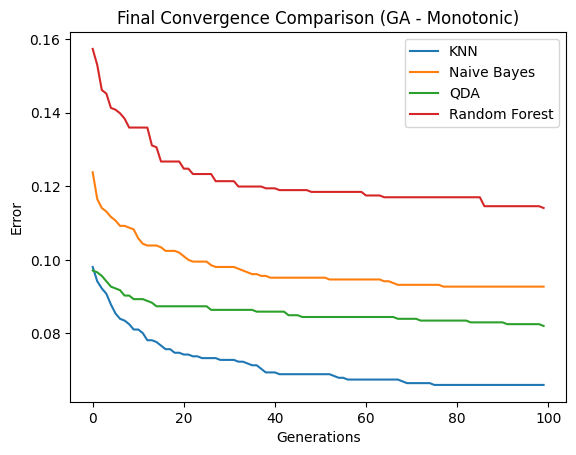


  Avg Execution Time : 461.2073 s
  Avg Memory Used    : 14.3275 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) -
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-PC4.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = [fitness(ind, model) for ind in population]

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running GA for KNN =====


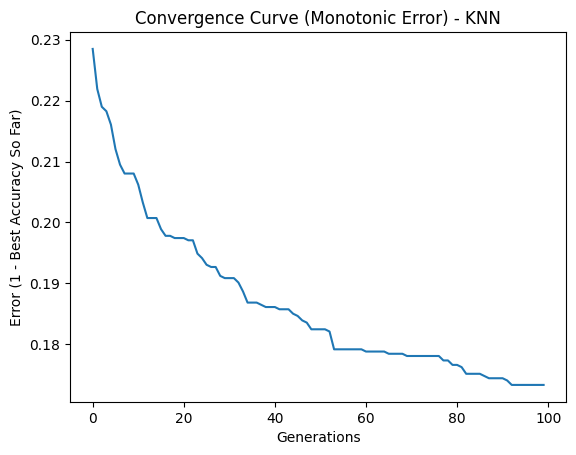

Selected Features: [2, 3, 4, 6, 7, 12, 13, 16, 19, 23, 27, 28, 29, 32, 35]
Without FS: {'Accuracy': 0.760932944606414, 'Precision': 0.5882352941176471, 'Recall': 0.425531914893617, 'F1': 0.49382716049382713}
With FS: {'Accuracy': 0.7434402332361516, 'Precision': 0.5405405405405406, 'Recall': 0.425531914893617, 'F1': 0.47619047619047616}

===== Running GA for Naive Bayes =====


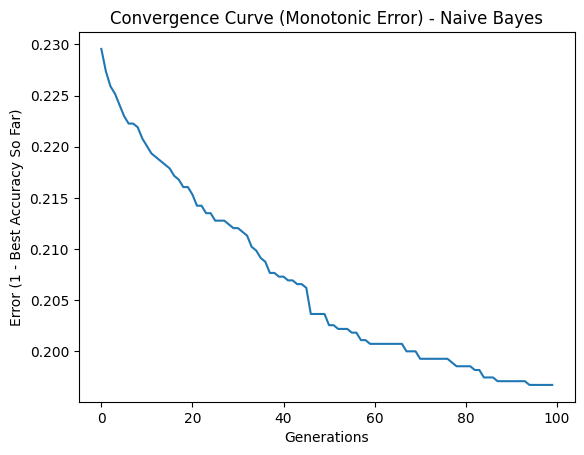

Selected Features: [0, 1, 4, 10, 11, 14, 15, 18, 19, 23, 24, 31, 35, 37]
Without FS: {'Accuracy': 0.749271137026239, 'Precision': 0.6176470588235294, 'Recall': 0.22340425531914893, 'F1': 0.328125}
With FS: {'Accuracy': 0.7230320699708455, 'Precision': 0.49056603773584906, 'Recall': 0.2765957446808511, 'F1': 0.35374149659863946}

===== Running GA for QDA =====


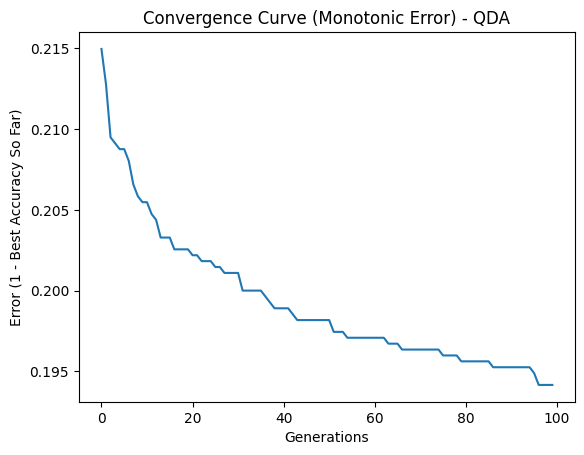

Selected Features: [0, 1, 6, 7, 8, 9, 11, 15, 16, 18, 23, 27, 28, 29, 30, 31, 33, 34, 35, 37]
Without FS: {'Accuracy': 0.7405247813411079, 'Precision': 0.5641025641025641, 'Recall': 0.23404255319148937, 'F1': 0.3308270676691729}
With FS: {'Accuracy': 0.7434402332361516, 'Precision': 0.575, 'Recall': 0.24468085106382978, 'F1': 0.34328358208955223}

===== Running GA for Random Forest =====


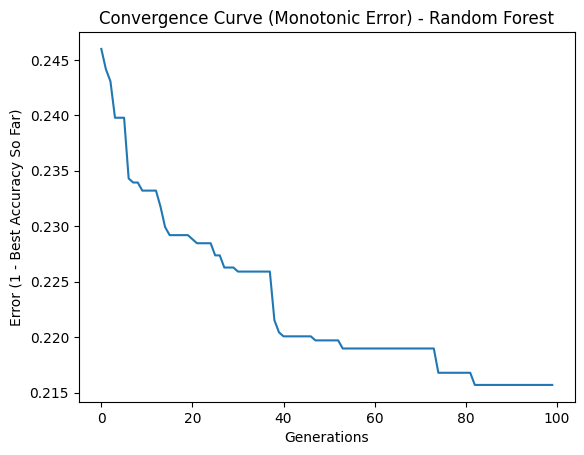

Selected Features: [0, 3, 4, 5, 6, 7, 8, 11, 13, 16, 17, 18, 19, 20, 21, 22, 24, 25, 27, 31, 33, 35, 38]
Without FS: {'Accuracy': 0.6967930029154519, 'Precision': 0.4609375, 'Recall': 0.6276595744680851, 'F1': 0.5315315315315315}
With FS: {'Accuracy': 0.6384839650145773, 'Precision': 0.4025974025974026, 'Recall': 0.6595744680851063, 'F1': 0.5}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.760933            0.743440   0.540541  0.425532   
1    Naive Bayes          0.749271            0.723032   0.490566  0.276596   
2            QDA          0.740525            0.743440   0.575000  0.244681   
3  Random Forest          0.696793            0.638484   0.402597  0.659574   

         F1  
0  0.476190  
1  0.353741  
2  0.343284  
3  0.500000  


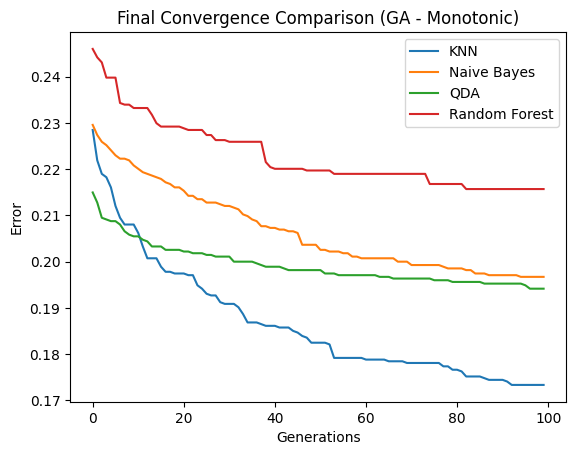


  Avg Execution Time : 477.6022 s
  Avg Memory Used    : 14.6948 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) -
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-PC5.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = [fitness(ind, model) for ind in population]

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")